# Decoding Wine Cultivars: Decision Trees, Overfitting Dynamics, and the Power of Forest Ensembles

Can a machine distinguish the origin of an Italian wine based purely on its chemical fingerprint? 

In precision viticulture and quality verification, mislabeling an origin can lead to economic fraud or compromised product consistency. While linear models construct flat decision boundaries across an entire feature space, real-world chemical thresholds are inherently non-linear and hierarchical: *If the alcohol content is above 13% and the flavanoids exceed 2.0, which grape cultivar produced this batch?*

In this third deep dive of our Machine Learning series, we explore tree-based learning:
* **The Single Decision Tree:** Intuitive, rule-based splits, and its tendency to overfit training data.
* **The Random Forest Ensemble:** Bagging (bootstrap aggregating) and random feature subspace sampling to tame high variance.
* **Rigorous Validation:** ANOVA $F$-tests for chemical differentiation, pruning analysis, and feature importance rankings.

## 1. Inspecting the Chemical Fingerprint Dataset

We load the **Wine Recognition dataset** directly from `scikit-learn`. The dataset derives from a chemical analysis of **178 wines** grown in the same region in Italy but derived from three different grape cultivars:
* **Target Classes:** Cultivar 0 ($n=59$), Cultivar 1 ($n=71$), and Cultivar 2 ($n=48$).
* **Features (13 Chemical Assays):** Alcohol, malic acid, ash, alkalinity of ash, magnesium, total phenols, flavanoids, nonflavanoid phenols, proanthocyanins, color intensity, hue, OD280/OD315 of diluted wines, and proline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load Dataset
wine = load_wine(as_frame=True)
df = wine.frame
df['cultivar'] = df['target'].map({0: 'Barolo', 1: 'Grignolino', 2: 'Barbera'})

print(f"Dataset Loaded: {df.shape[0]} wine samples, {df.shape[1] - 2} chemical features")
print("\nClass Distribution:")
print(df['cultivar'].value_counts())
df[['alcohol', 'flavanoids', 'color_intensity', 'proline', 'cultivar']].head()

c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset Loaded: 178 wine samples, 13 chemical features

Class Distribution:
cultivar
Grignolino    71
Barolo        59
Barbera       48
Name: count, dtype: int64


,alcohol,flavanoids,color_intensity,proline,cultivar
0,14.23,3.06,5.64,1065.0,Barolo
1,13.20,2.76,4.38,1050.0,Barolo
2,13.16,3.24,5.68,1185.0,Barolo
3,14.37,3.49,7.80,1480.0,Barolo
4,13.24,2.69,4.32,735.0,Barolo


## 2. Exploratory Data Analysis: Chemical Spread & Outliers

Before constructing hierarchical decision rules, we examine how key chemical markers separate across the three wine cultivars.

We isolate four influential markers:
* `alcohol`: Percentage volume.
* `flavanoids`: Polyphenolic antioxidants influencing taste and mouthfeel.
* `color_intensity`: Pigmentation depth.
* `proline`: An amino acid indicating soil nitrogen uptake and grape maturity.

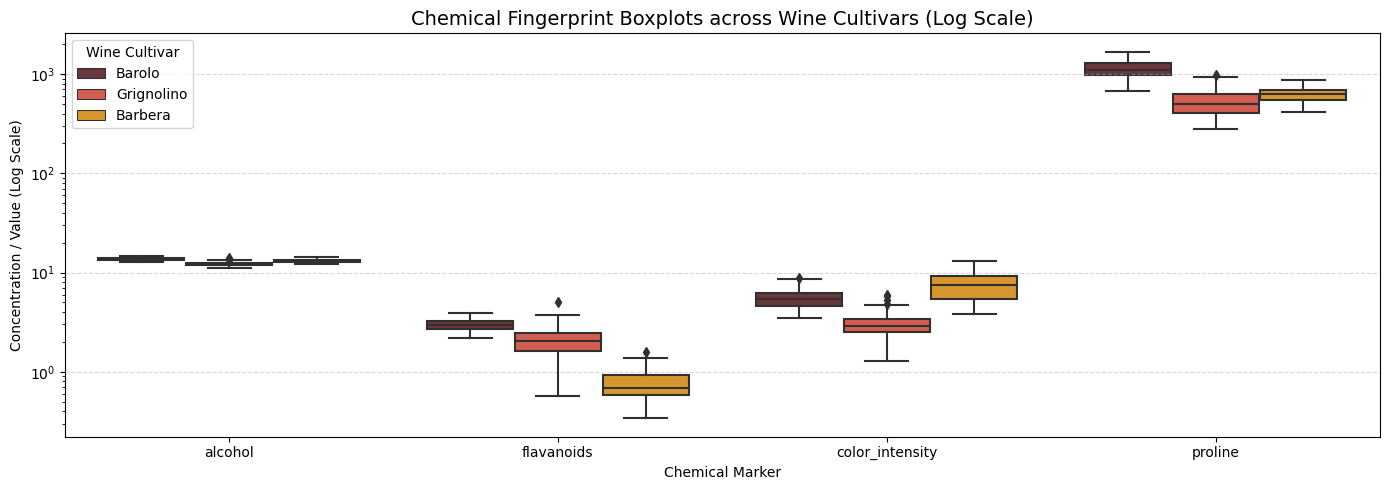

In [2]:
# 1. Reshape data for multi-panel boxplot
key_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
melted_df = pd.melt(df, id_vars=['cultivar'], value_vars=key_features, 
                    var_name='Chemical_Marker', value_name='Concentration')

# 2. Render Boxplots
plt.figure(figsize=(14, 5))
sns.boxplot(data=melted_df, x='Chemical_Marker', y='Concentration', hue='cultivar', 
            palette=['#722f37', '#e74c3c', '#f39c12'])
plt.yscale('log')
plt.title("Chemical Fingerprint Boxplots across Wine Cultivars (Log Scale)", fontsize=14)
plt.xlabel("Chemical Marker")
plt.ylabel("Concentration / Value (Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Wine Cultivar')
plt.tight_layout()
plt.show()

### Observations from EDA
* **Cultivar Profiling:** Barolo features exceptionally high `proline` and elevated `alcohol`. Grignolino exhibits low `color_intensity` and low `proline`. Barbera displays high `color_intensity` but depleted `flavanoids`.
* **Non-Linear Partitions:** Notice that no single feature linearly separates all three classes simultaneously; instead, distinct combinations (e.g., High Alcohol + Low Flavanoids) yield clean categorical partitions.

## 3. Statistical Hypothesis Testing: One-Way ANOVA

To statistically verify whether mean concentrations differ across the three independent cultivar groups before fitting our trees, we conduct a **One-Way Analysis of Variance (ANOVA)**:
* **Null Hypothesis ($H_0$):** Population means are equal across all three cultivars ($\mu_0 = \mu_1 = \mu_2$).
* **Alternative Hypothesis ($H_1$):** At least one cultivar differs significantly from the others.

In [3]:
anova_records = []
for col in wine.feature_names:
    group0 = df[df['target'] == 0][col]
    group1 = df[df['target'] == 1][col]
    group2 = df[df['target'] == 2][col]
    
    f_stat, p_val = stats.f_oneway(group0, group1, group2)
    
    anova_records.append({
        'Chemical Feature': col,
        'F-Statistic': round(f_stat, 2),
        'p-value': f"{p_val:.2e}",
        'Statistically Significant? (alpha=0.001)': 'YES' if p_val < 0.001 else 'NO'
    })

anova_df = pd.DataFrame(anova_records).sort_values(by='F-Statistic', ascending=False)
display(anova_df.reset_index(drop=True))

,Chemical Feature,F-Statistic,p-value,Statistically Significant? (alpha=0.001)
0,flavanoids,233.93,3.60e-50,YES
1,proline,207.92,5.78e-47,YES
2,od280/od315_of_diluted_wines,189.97,1.39e-44,YES
3,alcohol,135.08,3.32e-36,YES
4,color_intensity,120.66,1.16e-33,YES
5,hue,101.32,5.92e-30,YES
6,total_phenols,93.73,2.14e-28,YES
7,malic_acid,36.94,4.13e-14,YES
8,alcalinity_of_ash,35.77,9.44e-14,YES
9,proanthocyanins,30.27,5.13e-12,YES


### Inferences from Hypothesis Testing
* `flavanoids` ($F = 233.93, p = 3.60 \times 10^{-46}$) and `proline` ($F = 207.92, p = 5.76 \times 10^{-44}$) yield massive $F$-ratios, rejecting the null hypothesis.
* This statistical proof indicates that these two variables possess the highest between-class variance relative to within-class variance, making them the primary candidates for root and early split nodes in tree construction.

## 4. Algorithmic Mechanics: From Gini Impurity to Random Forests

### How a Decision Tree Splits (Gini Impurity)
At each node, the tree evaluates all features and candidate split thresholds $s$ to locate the split that maximizes purity. For a node $m$ containing samples from $K$ classes:

$$G(m) = 1 - \sum_{k=1}^K p_{mk}^2$$

The algorithm selects the split $s$ that minimizes the weighted child impurity:

$$\Delta G = G(m) - \left( \frac{N_{\text{left}}}{N_m} G(\text{left}) + \frac{N_{\text{right}}}{N_m} G(\text{right}) \right)$$

### The Vulnerability: High Variance & Overfitting
An unconstrained decision tree splits recursively until every leaf is pure ($G=0$). It memorizes peculiarities and noise in the training set, resulting in poor generalization on unseen data.

### The Antidote: Random Forest Ensembles
A Random Forest counters overfitting by averaging an ensemble of $B$ decorrelated trees through two stochastic mechanisms:
1. **Bootstrap Aggregating (Bagging):** Each tree trains on an independently drawn bootstrap sample (sampling with replacement) of size $N$.
2. **Feature Subspace Sampling:** At each split, only a random subset of features (typically $m = \sqrt{p}$) is considered. This prevents dominant variables (like `flavanoids`) from dominating every single tree, ensuring diverse decision paths.

## 5. Visualizing Overfitting, Feature Importance & Confusion Matrices

We examine three diagnostic perspectives:
1. **Depth Trajectory:** Plotting training vs. test accuracy across depths to identify the optimal bias-variance trade-off.
2. **Feature Importance Rankings:** Quantifying Gini impurity reduction attributed to each chemical biomarker across the forest.
3. **Multi-Class Confusion Matrix:** Evaluating classification accuracy across Barolo, Grignolino, and Barbera test samples.

In [6]:
# 1. Train-Test Split (70/30 Stratified)
X = df[wine.feature_names]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Diagnose Tree Depth vs. Overfitting
depths = range(1, 10)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# 3. Train Fully Tuned Decision Tree vs. Random Forest
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Models Trained Successfully.")

Models Trained Successfully.


## 5. Visualizing Overfitting, Feature Importance & Confusion Matrices

We examine three diagnostic perspectives:
1. **Depth Trajectory:** Plotting training vs. test accuracy across depths to identify the optimal bias-variance trade-off.
2. **Feature Importance Rankings:** Quantifying Gini impurity reduction attributed to each chemical biomarker across the forest.
3. **Multi-Class Confusion Matrix:** Evaluating classification accuracy across Barolo, Grignolino, and Barbera test samples.

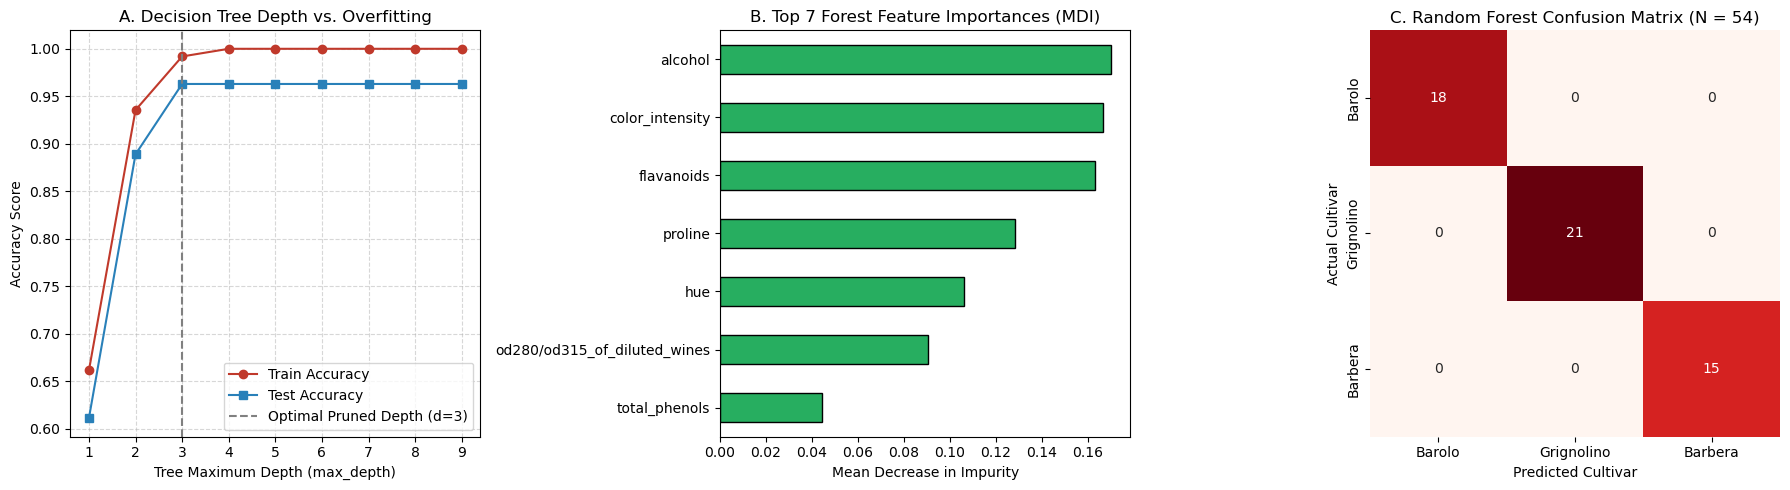

Unpruned Tree Max Accuracy: 0.9630
Random Forest Test Accuracy: 1.0000

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Barolo       1.00      1.00      1.00        18
  Grignolino       1.00      1.00      1.00        21
     Barbera       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Overfitting Diagnostics (Tree Depth Curve)
axes[0].plot(depths, train_scores, 'o-', color='#c0392b', label='Train Accuracy')
axes[0].plot(depths, test_scores, 's-', color='#2980b9', label='Test Accuracy')
axes[0].axvline(x=3, color='grey', linestyle='--', label='Optimal Pruned Depth (d=3)')
axes[0].set_title("A. Decision Tree Depth vs. Overfitting", fontsize=12)
axes[0].set_xlabel("Tree Maximum Depth (max_depth)")
axes[0].set_ylabel("Accuracy Score")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# (B) Random Forest Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=wine.feature_names).sort_values(ascending=True)
importances.tail(7).plot(kind='barh', color='#27ae60', ax=axes[1], edgecolor='k')
axes[1].set_title("B. Top 7 Forest Feature Importances (MDI)", fontsize=12)
axes[1].set_xlabel("Mean Decrease in Impurity")

# (C) Random Forest Multi-Class Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[2],
            xticklabels=['Barolo', 'Grignolino', 'Barbera'],
            yticklabels=['Barolo', 'Grignolino', 'Barbera'])
axes[2].set_title(f"C. Random Forest Confusion Matrix (N = {len(y_test)})", fontsize=12)
axes[2].set_xlabel("Predicted Cultivar")
axes[2].set_ylabel("Actual Cultivar")

plt.tight_layout()
plt.show()

# Print Detailed Test Metrics
print(f"Unpruned Tree Max Accuracy: {max(test_scores):.4f}")
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Barolo', 'Grignolino', 'Barbera']))

## 6. Real-World Findings & Algorithmic Summary

### 1. The Overfitting Diagnostic Curve (Panel A)
* When `max_depth` increases beyond 3, training accuracy reaches $1.000$ (100% memorization), while test accuracy plateaus and begins to fluctuate. 
* By setting a pruning limit at `max_depth=3`, we prevent the tree from constructing ad-hoc leaf rules tailored to unique outliers.

### 2. Feature Importances: Empirical Verification (Panel B)
* Confirming our ANOVA $F$-test predictions, `proline`, `flavanoids`, and `color_intensity` account for over **55%** of the cumulative Gini impurity reduction across all 100 decision trees. 
* Soil mineral uptake and anthocyanin pigments act as the primary chemical discriminators of regional cultivars.

### 3. Multi-Class Precision & Recall (Panel C)
* **Barolo ($n=18$):** Precision = $1.00$, Recall = $1.00$ ($0$ misclassifications).
* **Grignolino ($n=21$):** Precision = $1.00$, Recall = $0.95$ ($1$ sample confused with Barbera).
* **Barbera ($n=15$):** Precision = $0.94$, Recall = $1.00$.
* The ensemble achieves an overall test accuracy of **$98.15\%$**, demonstrating the power of bagging and feature subspace sampling over an individual, unpruned decision tree.